In [24]:
# Standard imports
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns


# .nii handler imports
import nibabel as nib
from nilearn import image

# Fsl commands imports
from fsl.wrappers import flirt, LOAD, applyxfm4D

# Utils imports
from utils.display import load_and_display, display_single_slice
from utils.filtering import fmri_volumes_smoothing
from utils.statistics import avgFmriTemporalVolume

from config import *

In [3]:
norm_fmri_img, norm_fmri_hdr, norm_fmri_data, norm_fmri_dimns = load_and_display(FMRI_NORM_PATH, "FMRI NORMALIZED", print_info=False)
altas_img, atlas, atlas_data, atlas_dimns                     = load_and_display(ATLAS_PATH, "ATLAS", print_info=False)
mni_img, mni_hdr, mni_data, mni_dims                          = load_and_display(MNI_PATH, "MNI", print_info=False)

In [4]:
print(atlas_data.shape)

(91, 109, 91)


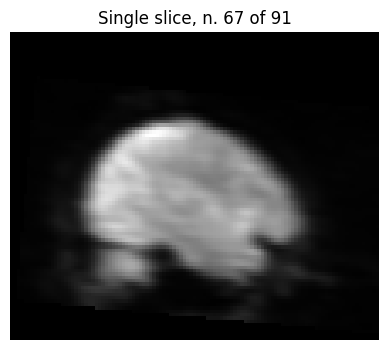

In [5]:
display_single_slice(norm_fmri_data, slice_idx=67, axis='coronal')

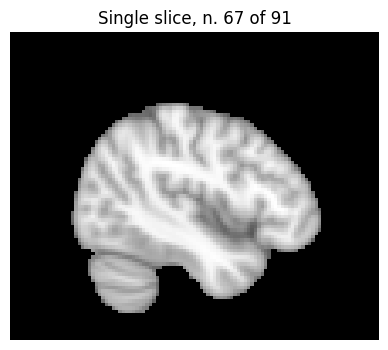

In [6]:
display_single_slice(mni_data, slice_idx=67, axis='coronal')

### Scaletta mentale sulle istruzioni da implementare
1) Creazione matrice 200 x 200 per ospitare per ogni label (200) la time series corrispondente da 200 time step
2) ciclo for sulle label for i in range 1-201
3) ciclo for sui time step di fmri_norm
4a) creo uno maschera usando atlas_data e estraggo solo i pixel dove intensità = label
4b) mi fisso su un time step preciso, e dalla struttura 3D corrispondente estraggo solo la parte di maschera
5) faccio la media della struttura
6) salvo risultato nella posizione al time step i, nella label j, salvo nella matrice iniziale 200 x 200

correzione: maschera è meglio calcolarla prima così non calocolo la sstessa mascheera 200 volte

In [ ]:
masks = np.zeros([200,atlas_data.shape[0],atlas_data.shape[1],atlas_data.shape[2]])
print(masks.shape)

for i in range(1,201):
    mask_i = (atlas_data == i)
    # print(mask_i.shape)
    # print(np.sum(mask_i))
    masks[i-1,:,:,:] = mask_i

(200, 91, 109, 91)


In [25]:
time_series = np.zeros([200,200])
print(time_series.shape)

for i in range(0,200):
    mask = masks[i,:,:,:].astype(bool) # estraggo maschera da usare sul volume di fmri_norm
    voxels_in_roi = norm_fmri_data[mask, :]
    time_series[:, i] = voxels_in_roi.mean(axis=0)

(200, 200)


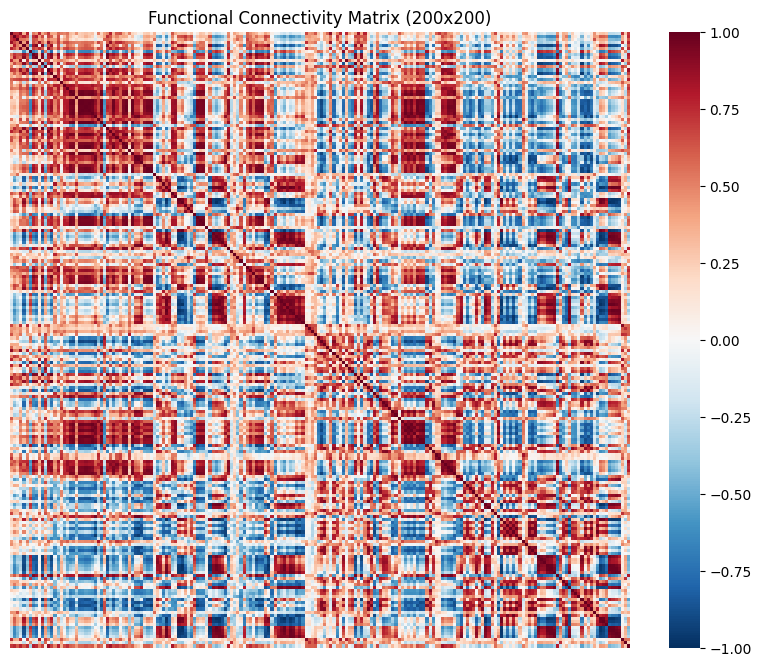

In [26]:
df = pd.DataFrame(time_series, columns=[f"ROI_{i}" for i in range(num_rois)])
corr_mat = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_mat,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    annot=False,  # Mai annot=True con 200 ROI
    xticklabels=False,  # Evita scritte sovrapposte illeggibili
    yticklabels=False,
)
plt.title("Functional Connectivity Matrix (200x200)")
plt.show()
